<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_93_CGAN_with_fashionMNIST_rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional GAN with fashion-MNIST
- https://machinelearningmastery.com/how-to-develop-a-conditional-generative-adversarial-network-from-scratch/



In [1]:
# ==========================================
# 한글 폰트 설치 및 설정 (Colab)
# ==========================================
import matplotlib.pyplot as plt

!apt-get -qq install fonts-nanum > /dev/null

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Reshape, Flatten, Conv2D, Input
from tensorflow.keras.layers import Conv2DTranspose, LeakyReLU, Dropout
from tensorflow.keras.layers import Embedding, Concatenate
from tensorflow.keras.utils import to_categorical

In [ ]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train', trainX.shape, trainy.shape)
print('Test', testX.shape, testy.shape)

4422102/4422102 [==============================] - 1s 0us/step
Train (60000, 28, 28) (60000,)
Test (10000, 28, 28) (10000,)


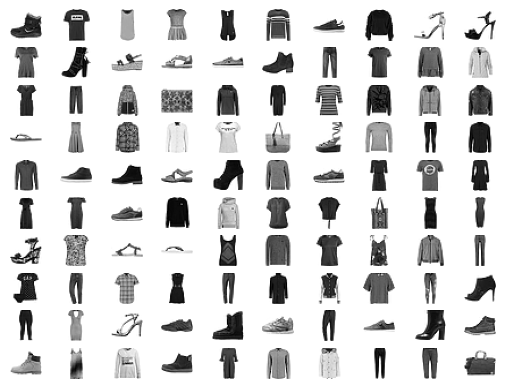

In [ ]:
for i in range(100):
	plt.subplot(10, 10, 1 + i)
	plt.axis('off')
	plt.imshow(trainX[i], cmap='gray_r')  # cmap = gray or gray_r
plt.show()

In [ ]:
set(trainy)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

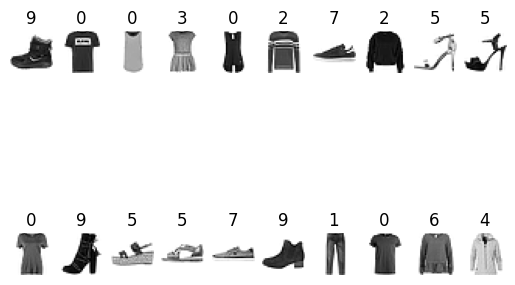

In [ ]:
for i in range(20):
    plt.subplot(2, 10, 1 + i)
    plt.axis('off')
    plt.imshow(trainX[i], cmap='gray_r')  # cmap = gray or gray_r
    plt.title(trainy[i])
plt.show()

- 0(t-shirt), 1(trouser), 2(pullover), 3(dress), 4(coat), 5(sandal), 6(shirt), 7(
sneaker), 8(bag), 9(ankle boot)

## Conditional GAN
- input: it takes additional information (labels, classes, etc.) as input along with random noise.
- output: it generates data samples conditioned on the provided information.
- objective: to generate data samples that not only resemble real data but also satisfy specific conditions provided as input.
- There are many ways to represent the class for cGAN, and the most widely used one is one-hot encoding and integer encoding. Here we use an Embedding layer to convert the classes into 50-dim vectors.
- We will use the functional API to re-implement the discriminator, generator, and the composite model.

- discriminator
  - a new second input is defined that takes an integer for the class label of the image. This has the effect of making the input image conditional on the provided class label.
  - The class label is then passed through an Embedding layer with the size of 50. This means that each of the 10 classes for the Fashion MNIST dataset (0 through 9) will map to a different 50-element vector representation that will be learned by the discriminator model.
- generator
  - must be updated to take the class label. This has the effect of making the point in the latent space conditional on the provided class label.
  - the class label is passed through an embedding layer to map it to a unique 50-element vector and is then passed through a fully connected layer with a linear activation before being resized.
  - The new 7×7 feature map is added as one more channel to the existing 128, resulting in 129 feature maps that are then upsampled as in the prior model.

In [ ]:
# define the standalone discriminator model
def define_discriminator(in_shape=(28,28,1), n_classes=10):

	in_label = Input(shape=(1,))              # (class) label input
	li = Embedding(n_classes, 50)(in_label)   # embedding for categorical class input
	n_nodes = in_shape[0] * in_shape[1]       # no of flattened nodes
	li = Dense(n_nodes)(li)
	li = Reshape((in_shape[0], in_shape[1], 1))(li)  # reshape to additional channel

	in_image = Input(shape=in_shape)          # image input
	merge = Concatenate()([in_image, li])     # concat image with label

	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(merge)
	fe = LeakyReLU(alpha=0.2)(fe)
	fe = Conv2D(128, (3,3), strides=(2,2), padding='same')(fe)
	fe = LeakyReLU(alpha=0.2)(fe)
	fe = Flatten()(fe)
	fe = Dropout(0.4)(fe)
	out_layer = Dense(1, activation='sigmoid')(fe)

	model = Model([in_image, in_label], out_layer)
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
	return model

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 embedding (Embedding)       (None, 1, 50)                500       ['input_1[0][0]']             
                                                                                                  
 dense (Dense)               (None, 1, 784)               39984     ['embedding[0][0]']           
                                                                                                  
 input_2 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                              

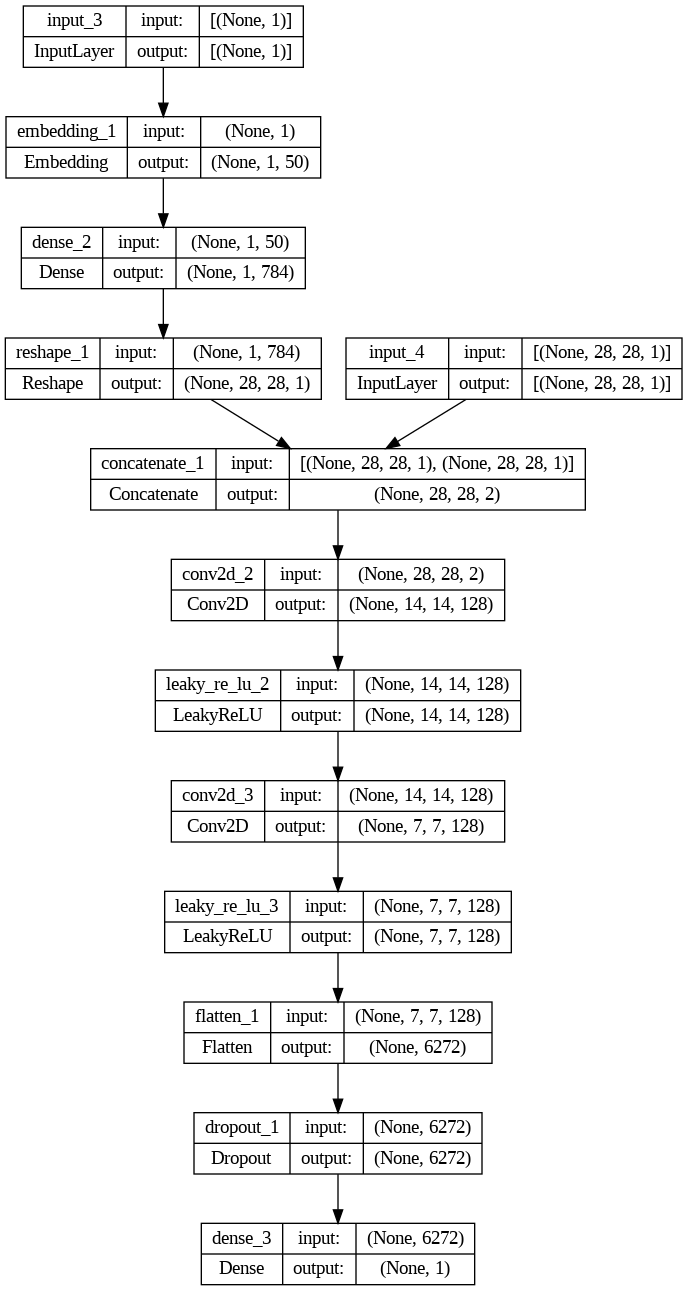

In [ ]:
define_discriminator().summary()
keras.utils.plot_model(define_discriminator(), "cgan_encoder.png", show_shapes=True)

- As in the discriminator, the class label is passed through an embedding layer to map it to a unique 50-element vector and is then passed through a fully connected layer with a linear activation before being resized.
- In this case, the activations of the fully connected layer are resized into a single 7×7 feature map. This is to match the 7×7 feature map activations of the unconditional generator model.
- The new 7×7 feature map is added as one more channel to the existing 128, resulting in 129 feature maps that are then upsampled as in the prior model.

In [ ]:
# define the standalone generator model
def define_generator(latent_dim, n_classes=10):

	in_label = Input(shape=(1,))            # label input
	li = Embedding(n_classes, 50)(in_label) # embedding for categorical input
	li = Dense(7 * 7)(li)                   # linear multiplication
	li = Reshape((7, 7, 1))(li)

	in_lat = Input(shape=(latent_dim,))     # image generator input
	n_nodes = 128 * 7 * 7                   # foundation for 7x7 image
	gen = Dense(n_nodes)(in_lat)
	gen = LeakyReLU(alpha=0.2)(gen)
	gen = Reshape((7, 7, 128))(gen)

	merge = Concatenate()([gen, li])        # merge image gen and label input
	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(merge) # upsample to 14x14
	gen = LeakyReLU(alpha=0.2)(gen)
	gen = Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')(gen)   # upsample to 28x28
	gen = LeakyReLU(alpha=0.2)(gen)
	out_layer = Conv2D(1, (7,7), activation='tanh', padding='same')(gen)

	model = Model([in_lat, in_label], out_layer)
	return model

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_10 (InputLayer)       [(None, 100)]                0         []                            
                                                                                                  
 input_9 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 dense_9 (Dense)             (None, 6272)                 633472    ['input_10[0][0]']            
                                                                                                  
 embedding_4 (Embedding)     (None, 1, 50)                500       ['input_9[0][0]']             
                                                                                            

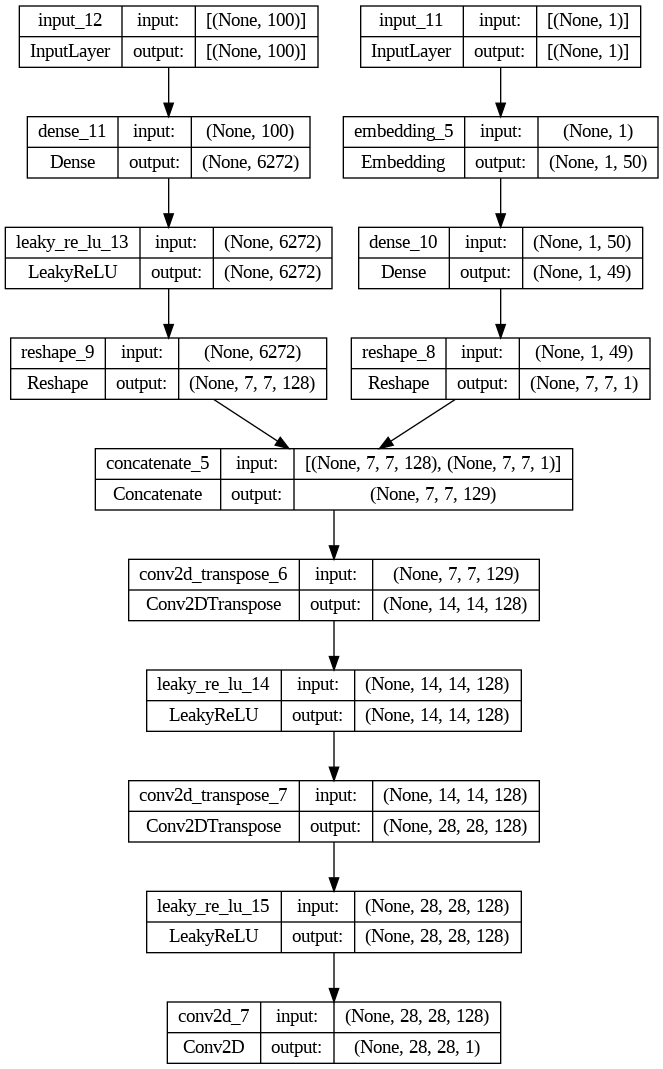

In [ ]:
define_generator(100).summary()
keras.utils.plot_model(define_generator(100), "cgan_encoder.png", show_shapes=True)

In [ ]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(g_model, d_model):

	d_model.trainable = False
	# get noise and label inputs from generator model
	gen_noise, gen_label = g_model.input
	# get image output from the generator model
	gen_output = g_model.output
	# connect image output and label input from generator as inputs to discriminator
	gan_output = d_model([gen_output, gen_label])
	# define gan model as taking noise and label and outputting a classification
	model = Model([gen_noise, gen_label], gan_output)

	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt)
	return model

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_18 (InputLayer)       [(None, 100)]                0         []                            
                                                                                                  
 input_17 (InputLayer)       [(None, 1)]                  0         []                            
                                                                                                  
 dense_17 (Dense)            (None, 6272)                 633472    ['input_18[0][0]']            
                                                                                                  
 embedding_8 (Embedding)     (None, 1, 50)                500       ['input_17[0][0]']            
                                                                                           

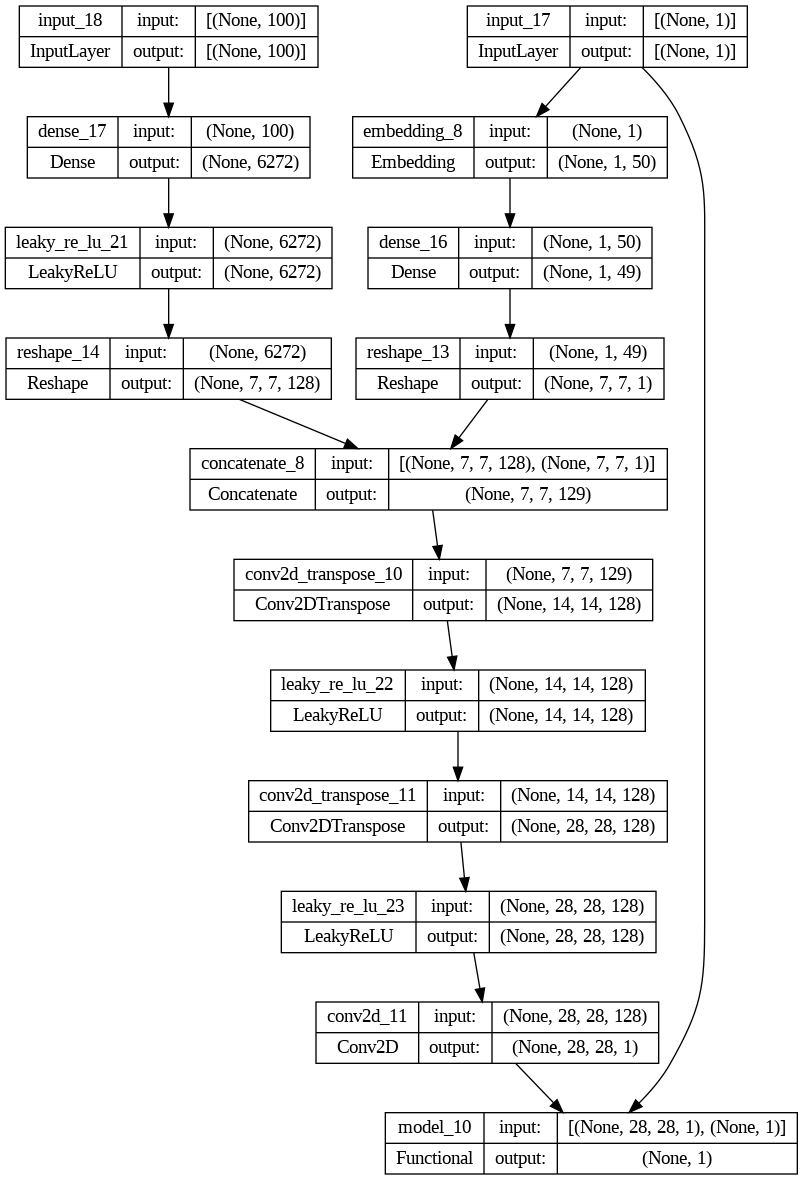

In [ ]:
all = define_gan(define_generator(100), define_discriminator())
all.summary()
keras.utils.plot_model(all, "all.png", show_shapes=True)

In [ ]:
# load fashion mnist images
def load_real_samples():
	# load dataset
	(trainX, trainy), (_, _) = fashion_mnist.load_data()
	# expand to 3d, e.g. add channels
	X = np.expand_dims(trainX, axis=-1)
	# convert from ints to floats
	X = X.astype('float32')
	# scale from [0,255] to [-1,1]
	X = (X - 127.5) / 127.5
	return [X, trainy]

# select real samples
def generate_real_samples(dataset, n_samples):
	# split into images and labels
	images, labels = dataset
	# choose random instances
	ix = np.random.randint(0, images.shape[0], n_samples)  # tf does not have randint
	# select images and labels
	X, labels = images[ix], labels[ix]
	# generate class labels
	y = np.ones((n_samples, 1))
	return [X, labels], y

In [ ]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples, n_classes=10):
	# generate points in the latent space
	x_input = np.random.randn(latent_dim * n_samples)
	# reshape into a batch of inputs for the network
	z_input = x_input.reshape(n_samples, latent_dim)
	# generate labels
	labels = np.random.randint(0, n_classes, n_samples)
	return [z_input, labels]

# use the generator to generate n fake examples, with class labels
def generate_fake_samples(generator, latent_dim, n_samples):
	# generate points in latent space
	z_input, labels_input = generate_latent_points(latent_dim, n_samples)
	# predict outputs
	images = generator.predict([z_input, labels_input])
	# create class labels
	y = np.zeros((n_samples, 1))
	return [images, labels_input], y

In [ ]:
# train the generator and discriminator
from tqdm import tqdm

def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=10, n_batch=128): # n_epochs=100
	bat_per_epo = int(dataset[0].shape[0] / n_batch)
	half_batch = int(n_batch / 2)
	# manually enumerate epochs
	for i in tqdm(range(n_epochs)):
		# enumerate batches over the training set
		for j in range(bat_per_epo):
			# get randomly selected 'real' samples
			[X_real, labels_real], y_real = generate_real_samples(dataset, half_batch)
			# update discriminator model weights
			d_loss1, _ = d_model.train_on_batch([X_real, labels_real], y_real)
			# generate 'fake' examples
			[X_fake, labels], y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			# update discriminator model weights
			d_loss2, _ = d_model.train_on_batch([X_fake, labels], y_fake)
			# prepare points in latent space as input for the generator
			[z_input, labels_input] = generate_latent_points(latent_dim, n_batch)
			# create inverted labels for the fake samples
			y_gan = np.ones((n_batch, 1))
			# update the generator via the discriminator's error
			g_loss = gan_model.train_on_batch([z_input, labels_input], y_gan)
			# summarize loss on this batch
			print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' %
				(i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))
	# save the generator model
	g_model.save('cgan_generator.h5')

In [ ]:
# size of the latent space
latent_dim = 100
# create the discriminator
d_model = define_discriminator()
# create the generator
g_model = define_generator(latent_dim)
# create the gan
gan_model = define_gan(g_model, d_model)
# load image data
dataset = load_real_samples()
# train model
train(g_model, d_model, gan_model, dataset, latent_dim)

## conditional clothing generation

In [ ]:
# foir reference
print([x for _ in range(4) for x in range(5)])

[0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4]


In [ ]:
# for reference
X = model.predict([latent_points, labels])
X.shape, X.max(), X.min()

4/4 [==============================] - 0s 3ms/step


4/4 [==============================] - 0s 27ms/step


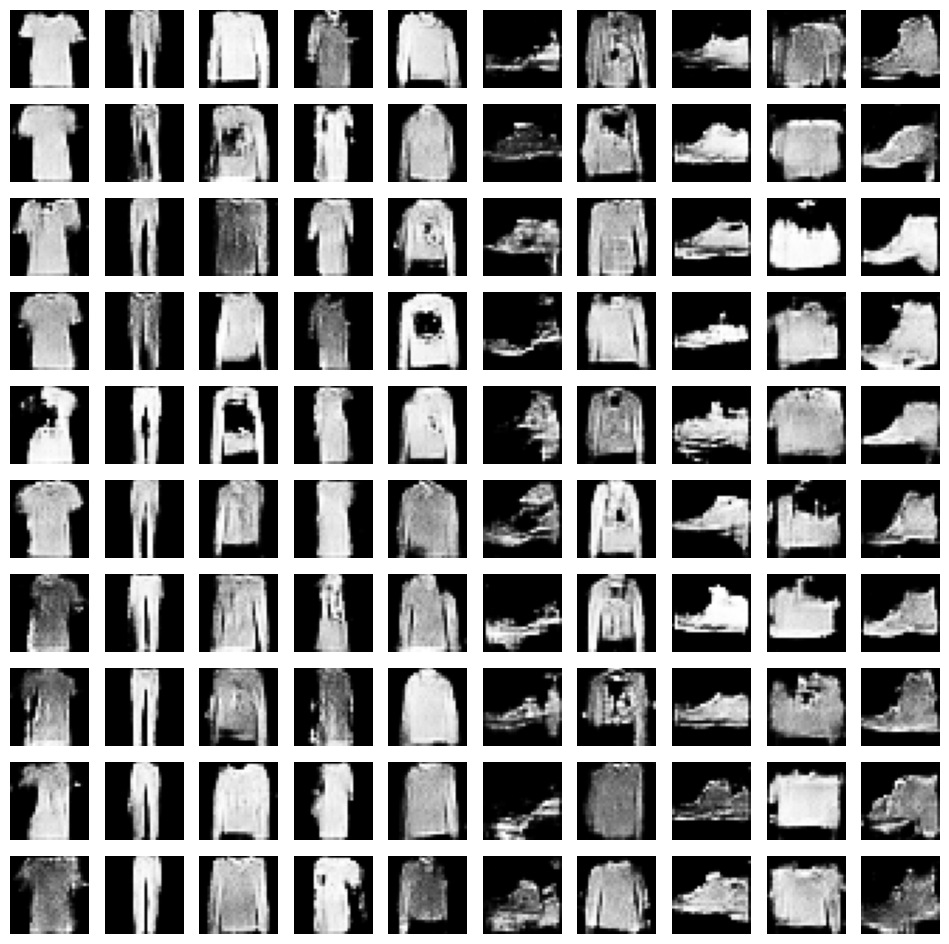

In [ ]:
# example of loading the generator model and generating images
from numpy import asarray
from numpy.random import randn
from numpy.random import randint
from keras.models import load_model
import matplotlib.pyplot as plt

# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples, n_classes=10):
	x_input = randn(latent_dim * n_samples)           # generate points in the latent space
	z_input = x_input.reshape(n_samples, latent_dim)  # reshape into a batch of inputs for the network
	labels = randint(0, n_classes, n_samples)         # generate labels
	return [z_input, labels]

# create and save a plot of generated images
def save_plot(examples, n):
	plt.figure(figsize=(12,12))
	for i in range(n * n):
		plt.subplot(n, n, 1 + i)
		plt.axis('off')
		# plt.imshow(examples[i, :, :, 0], cmap='gray_r')
		plt.imshow(examples[i, :, :, 0], cmap='gray')
	plt.show()

# load model
model = load_model('cgan_generator.h5')

latent_points, labels = generate_latent_points(100, 100)
labels = asarray([x for _ in range(10) for x in range(10)])

X  = model.predict([latent_points, labels])  # generate images

X = (X + 1) / 2.0    # scale from [-1,1] to [0,1]

save_plot(X, 10)

- The clothing is organized in columns. From left to right, they are “t-shirt“, ‘trouser‘, ‘pullover‘, ‘dress‘, ‘coat‘, ‘sandal‘, ‘shirt‘, ‘sneaker‘, ‘bag‘, and ‘ankle boot‘.

- We can see not only are the randomly generated items of clothing plausible, but they also match their expected category.

- Compared with a standard GAN, the cGAN's advantage lies in its ability to generate images with specific attributes or characteristics defined by the condition, which can be a powerful feature depending on the application.
- If the conditional information is well-structured and relevant to the generation task, the cGAN can potentially produce images of similar or even better quality compared to a standard GAN.


# Another version (Recommended)

In [6]:
import tensorflow.keras as keras
from tensorflow.keras import layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 하이퍼파라미터 & 데이터
# ==========================================
latent_dim = 100
n_classes = 10
batch_size = 128
embedding_dim = 20   # 라벨의 임베딩 차원: 50 까지 될 정도가 아니라 20으로 수정
epochs = 10

(x_train, y_train), (_, _) = keras.datasets.fashion_mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1).astype("float32")
x_train = (x_train - 127.5) / 127.5   # [-1, 1]
y_train = y_train.astype("int32")

dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size, drop_remainder=True)

# ==========================================
# 2. Discriminator — 이미지 + 레이블을 함께 입력받음
# ==========================================
in_image = layers.Input(shape=(28, 28, 1), name="image_input")
in_label = layers.Input(shape=(1,), name="label_input")

# 레이블을 임베딩한 뒤, 이미지와 같은 (28,28,1) 모양으로 만들어 채널로 합침
li = layers.Embedding(n_classes, embedding_dim)(in_label)
li = layers.Dense(28 * 28)(li)
li = layers.Reshape((28, 28, 1))(li)

merged = layers.Concatenate()([in_image, li])   # (28, 28, 2)

fe = layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same")(merged)
fe = layers.LeakyReLU(negative_slope=0.2)(fe)
fe = layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same")(fe)
fe = layers.LeakyReLU(negative_slope=0.2)(fe)
fe = layers.Flatten()(fe)
fe = layers.Dropout(0.4)(fe)
out = layers.Dense(1, activation="sigmoid")(fe)

discriminator = keras.Model([in_image, in_label], out, name="discriminator")

# ==========================================
# 3. Generator — 잠재벡터 + 레이블을 함께 입력받음
# ==========================================
in_lat = layers.Input(shape=(latent_dim,), name="latent_input")
in_label_g = layers.Input(shape=(1,), name="label_input_g")

li_g = layers.Embedding(n_classes, embedding_dim)(in_label_g)
li_g = layers.Dense(7 * 7)(li_g)
li_g = layers.Reshape((7, 7, 1))(li_g)

gen = layers.Dense(128 * 7 * 7)(in_lat)
gen = layers.BatchNormalization()(gen)
gen = layers.LeakyReLU(negative_slope=0.2)(gen)
gen = layers.Reshape((7, 7, 128))(gen)

merged_g = layers.Concatenate()([gen, li_g])    # (7, 7, 129)

gen = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same")(merged_g)
gen = layers.BatchNormalization()(gen)
gen = layers.LeakyReLU(negative_slope=0.2)(gen)

gen = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same")(gen)
gen = layers.BatchNormalization()(gen)
gen = layers.LeakyReLU(negative_slope=0.2)(gen)

out_g = layers.Conv2D(1, (7, 7), activation="tanh", padding="same")(gen)

generator = keras.Model([in_lat, in_label_g], out_g, name="generator")

# ==========================================
# 4. CGAN — train_step()에 레이블 조건만 추가
# ==========================================
class CGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim, n_classes, **kwargs):
        super().__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.n_classes = n_classes
        self.loss_fn = keras.losses.BinaryCrossentropy()
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer

    def train_step(self, data):
        real_images, real_labels = data
        batch_size = tf.shape(real_images)[0]
        real_labels = tf.reshape(real_labels, (-1, 1))

        # ---- Discriminator ----
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        fake_labels = tf.random.uniform(
            (batch_size, 1), minval=0, maxval=self.n_classes, dtype=tf.int32
        )
        fake_images = self.generator([random_latent_vectors, fake_labels])

        combined_images = tf.concat([real_images, fake_images], axis=0)
        combined_labels = tf.concat([real_labels, fake_labels], axis=0)
        targets = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0
        )

        with tf.GradientTape() as tape:
            predictions = self.discriminator([combined_images, combined_labels])
            d_loss = self.loss_fn(targets, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # ---- Generator ----
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        random_labels = tf.random.uniform(
            (batch_size, 1), minval=0, maxval=self.n_classes, dtype=tf.int32
        )
        misleading_targets = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, random_labels])
            predictions = self.discriminator([fake_images, random_labels])
            g_loss = self.loss_fn(misleading_targets, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}


cgan = CGAN(generator, discriminator, latent_dim, n_classes)
cgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
)

history = cgan.fit(dataset, epochs=epochs)

cgan.generator.save("cgan_generator.keras")

Epoch 1/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - d_loss: 0.6378 - g_loss: 0.8222
Epoch 2/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6273 - g_loss: 0.8575
Epoch 3/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6261 - g_loss: 0.8445
Epoch 4/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6062 - g_loss: 0.8654
Epoch 5/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6170 - g_loss: 0.8626
Epoch 6/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6270 - g_loss: 0.8531
Epoch 7/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6286 - g_loss: 0.8279
Epoch 8/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6394 - g_loss: 0.8154
Epoch 9/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6384 - g_loss: 0.8108
Epoch 10/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - d_loss: 0.6388 - g_loss: 0.8156


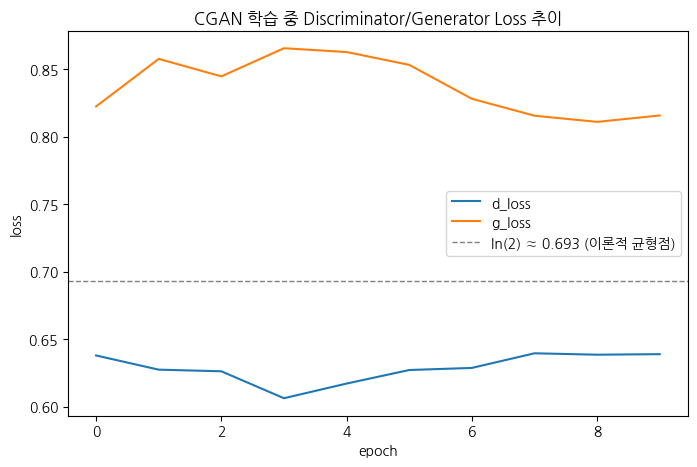

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["d_loss"], label="d_loss")
plt.plot(history.history["g_loss"], label="g_loss")
plt.axhline(y=0.693, color="gray", linestyle="--", linewidth=1, label="ln(2) ≈ 0.693 (이론적 균형점)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("CGAN 학습 중 Discriminator/Generator Loss 추이")
plt.show()

- 일반 GAN과 같은 기준을 그대로 적용하면 된다. — GAN 의 경우와 같이 ln(2) ≈ 0.693 근처에서 두 loss가 서로 밀고 당기며 안정되는지가 핵심.
  - d_loss가 0 근처로 떨어지고 g_loss가 계속 치솟으면 → discriminator 완승 (붕괴 위험, 지난번 겪으셨던 검은 이미지 패턴)
  - 반대로 g_loss가 0 근처로 떨어지면 → generator가 너무 쉽게 이김
- CGAN 에서 다르게 볼 점:
  - discriminator가 이번엔 "진짜냐 가짜냐"뿐 아니라 "레이블과 이미지가 실제로 맞는 조합인가"까지 같이 판단해야 해서, 일반 GAN보다 discriminator의 task가 더 어렵다.
  - 따라서, d_loss가 일반 GAN 때보다 살짝 더 높게(즉 discriminator가 상대적으로 덜 유리하게) 유지되는 경향이 있으면, 그건 정상적인 현상이다. - "조건까지 맞춰서 구별해야 하니 판별이 더 까다로워졌다"는 의미.
- loss 곡선만으로는 "레이블이 실제로 잘 반영됐는지"는 알 수 없다.
  - 예를 들어 label=3을 넣었는데 실제로는 그럴듯한 아무 이미지나 나와도 discriminator/generator 입장에서는 loss가 낮게 나올 수 있다.
  - 따라서, 앞서 만든 "행마다 클래스가 다른 10x10 그리드" 이미지를 loss 그래프와 같이 놓고 보는게 좋음. — loss가 좋아 보이는데 그리드에서 클래스 구분이 안 된다면, 그건 레이블 컨디셔닝 자체가 제대로 학습이 안 된 신호.

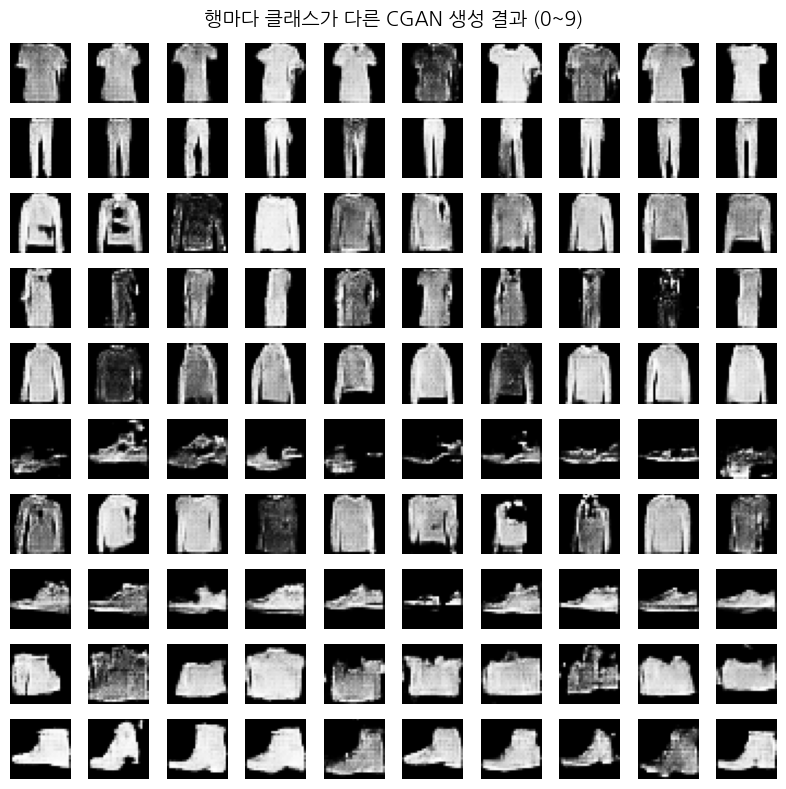

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 생성 결과 확인 — 클래스별로 행을 구분
# ==========================================
loaded_generator = keras.models.load_model("cgan_generator.keras")

n = 10  # n x n 그리드 (각 행 = 클래스 0~9)
random_latent_vectors = tf.random.normal(shape=(n * n, latent_dim))
labels = np.array([c for c in range(n) for _ in range(n)]).reshape(-1, 1)

generated_images = loaded_generator.predict([random_latent_vectors, labels], verbose=0)
generated_images = (generated_images * 127.5 + 127.5).astype("uint8")

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i, :, :, 0], cmap="gray")
    ax.axis("off")

plt.suptitle("행마다 클래스가 다른 CGAN 생성 결과 (0~9)", fontsize=14)
plt.tight_layout()
plt.show()

# Exercise